In [67]:
!pip install pandas
!pip install pyarrow
!pip install seaborn
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 8.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 10.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [95]:
import pandas as pd
import json

In [96]:
import pandas as pd
import pyarrow.parquet as pq

# đọc Parquet bằng pyarrow
table = pq.read_table('../data/medicalqa.parquet')
df = table.to_pandas()

# kiểm tra các cột kiểu Period
for col in df.columns:
    if pd.api.types.is_period_dtype(df[col]):
        print(f"Converting column {col} from Period to string")
        df[col] = df[col].astype(str)

df.head()

/tmp/ipykernel_8912/534526473.py:10: Pandas4Warning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):


,answer,question
0,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nRăng cháu hiện tại có mủ ở dưới ..."
1,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nEm thấy mặt dưới, phía cuống lưỡ..."
2,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nTừ tháng 4/2020, em mới xuất hiệ..."
3,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nDạo gần đây, mỗi tối ngủ con hay..."
4,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nEm bị tăng tiết mồ hôi, nhất là ..."


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9335 entries, 0 to 9334
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   answer    9335 non-null   str  
 1   question  9335 non-null   str  
dtypes: str(2)
memory usage: 146.0 KB


In [98]:
df.shape
df.dtypes
df.isnull().sum()

answer      0
question    0
dtype: int64

In [99]:
duplicate_questions = df[df['question'].duplicated(keep=False)]
duplicate_questions[['question','answer']]

,question,answer
1952,Kết quả xét nghiệm gan Anti HBs - Positive 769...,"Chào bạn, xin được giải thích ý nghĩa 2 kết qu..."
2119,Kết quả xét nghiệm gan Anti HBs - Positive 769...,"Chào bạn, xin được giải thích ý nghĩa 2 kết qu..."
4528,Chào bác sĩ. Em có đi cắt bao quy đầu ở một ph...,"Chào bạn!\nTrước hết, cảm ơn bạn đã chia sẻ bă..."
4633,Chào bác sĩ. Em có đi cắt bao quy đầu ở một ph...,"Chào bạn!\nTrước hết, cảm ơn bạn đã chia sẻ bă..."
6032,chào bác sĩ cho e hỏi thai 35w2 ngày bé 2kg1 c...,chào bạn: trường hợp của bạn khá phức tạp! như...
6041,chào bác sĩ cho e hỏi thai 35w2 ngày bé 2kg1 c...,chào bạn: bạn như vậy có nguy cơ bị tiền sản g...
6548,"Xin chào bác sĩ,\nE muốn hỏi là lưỡi e bị trắn...",Chào bạn\nVới thông tin bạn đưa ra thì chúng t...
6673,"Xin chào bác sĩ,\nE muốn hỏi là lưỡi e bị trắn...",Có thể em đang bị viêm hệ thống amidan vung họ...
7933,"Xin chào bác sĩ,\nE mới sinh cháu được hai tha...",Chào bạn \nTình trạng của bạn có thể là do tắc...
8199,"Tôi hay bị đau ở ngực,thường xuyên bị khó thở,...","Chào bạn!\nĐau ngực thường xuyên và khó thở, h..."


In [100]:
df_clean = df.drop_duplicates(subset='question')

In [101]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 9329 entries, 0 to 9334
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   answer    9329 non-null   str  
 1   question  9329 non-null   str  
dtypes: str(2)
memory usage: 218.6 KB


In [102]:
df_clean['q_len'] = df_clean['question'].apply(lambda x: len(str(x).split()))
df_clean['a_len'] = df_clean['answer'].apply(lambda x: len(str(x).split()))

df_clean[['q_len','a_len']].describe()

,q_len,a_len
count,9329.000000,9329.000000
mean,63.788938,131.771787
std,46.880051,115.014757
min,3.000000,1.000000
25%,36.000000,69.000000
50%,54.000000,101.000000
75%,79.000000,157.000000
max,1451.000000,2000.000000


In [103]:
df_clean.loc[df_clean['a_len'].idxmax()]

answer      Chào bạn,\nVới câu hỏi: "Nhức đầu liền 3 ngày ...
question    Em bị nhức đầu liền 3 ngày hôm nay. Nhức ở phầ...
q_len                                                     118
a_len                                                    2000
Name: 4983, dtype: object

In [104]:
df_clean.loc[df_clean['q_len'].idxmax()]

answer      Chào bạn!\nTrên thị trường hiện nay lưu hành c...
question    Chào bác sĩ. Cho em hỏi sau khi quan hệ không ...
q_len                                                    1451
a_len                                                     193
Name: 3922, dtype: object

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

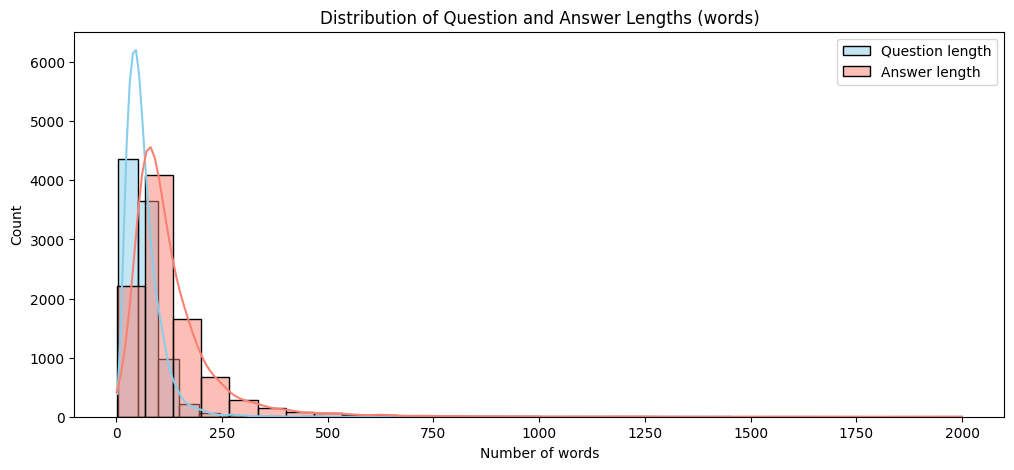

In [106]:
plt.figure(figsize=(12,5))

# Histogram answers
sns.histplot(df_clean['q_len'], bins=30, kde=True, color='skyblue', label='Question length')
# Histogram questions
sns.histplot(df_clean['a_len'], bins=30, kde=True, color='salmon', label='Answer length')

plt.title('Distribution of Question and Answer Lengths (words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.legend()
plt.show()

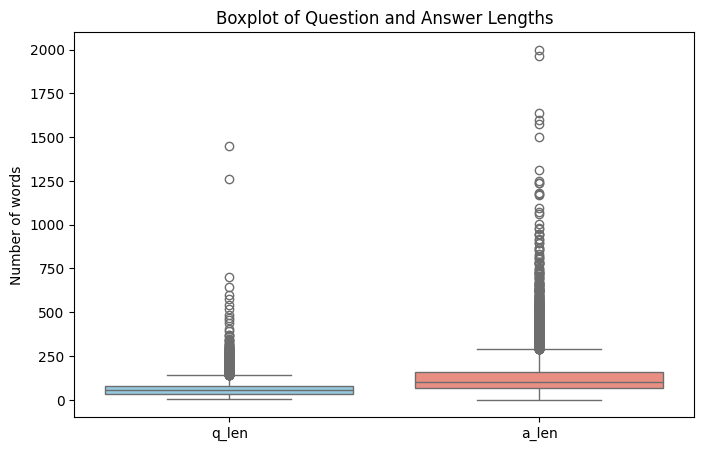

In [107]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean[['q_len','a_len']], palette=['skyblue','salmon'])
plt.title('Boxplot of Question and Answer Lengths')
plt.ylabel('Number of words')
plt.show()

In [108]:
from typing import Tuple
from sklearn.base import BaseEstimator, TransformerMixin


def find_boxplot_boundaries(
    col: pd.Series, whisker_coeff: float = 1.5
) -> Tuple[float, float]:
    """Findx minimum and maximum in boxplot.

    Args:
        col: a pandas serires of input.
        whisker_coeff: whisker coefficient in box plot
    """
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - whisker_coeff * IQR
    upper = Q3 + whisker_coeff * IQR
    return lower, upper


class BoxplotOutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, whisker_coeff: float = 1.5):
        self.whisker = whisker_coeff
        self.lower = None
        self.upper = None

    def fit(self, X: pd.Series):
        self.lower, self.upper = find_boxplot_boundaries(X, self.whisker)
        return self

    def transform(self, X):
        return X.clip(self.lower, self.upper)

In [109]:
cols = ['q_len', 'a_len']
for col in cols:
    df_clean[col] = BoxplotOutlierClipper().fit_transform(df_clean[col])

In [110]:
len(df_clean)

9329

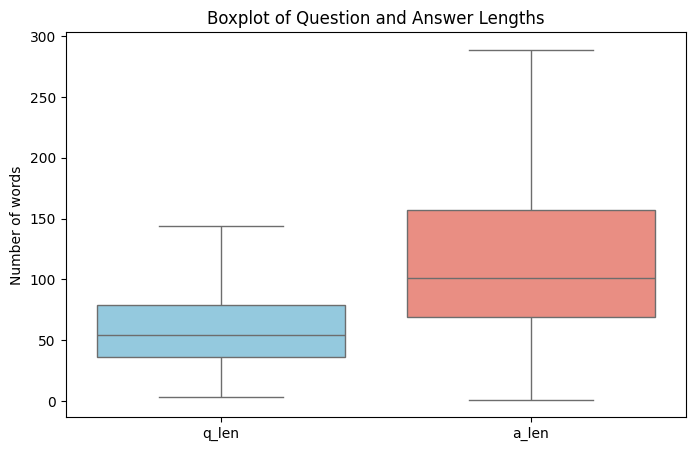

In [111]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean[['q_len','a_len']], palette=['skyblue','salmon'])
plt.title('Boxplot of Question and Answer Lengths')
plt.ylabel('Number of words')
plt.show()

In [112]:
short_answers = df_clean[df_clean['a_len'] < 3]
print(short_answers)

                        answer  \
1668                 Chào bạn,   
1969                  Chào Em!   
2148                 Chào bạn,   
2496                Chào cháu,   
2664                 Chào bạn!   
2843                 Chào bạn!   
3038                  Chào em!   
3088                  Chào bạn   
3302                  Chào em!   
3334                 Chào bạn!   
3414                 Chào bạn,   
3576                  Chào em!   
3803                 Chào bạn,   
3846                 Chào bạn,   
4151                  Chào em!   
4653                 Chào bạn!   
4656                 Chào bạn!   
4727                  Chào em!   
7308  20.000.000đ-100.000.000đ   

                                               question  q_len  a_len  
1668  Chào bác sĩ, mẹ em bị ho nhiều mỗi khi ăn cơm ...   49.0      2  
1969  Xin chào bác sĩ! Em đi khám da liễu, bác sĩ ch...   68.0      2  
2148  Chào bác sĩ, hay ho khan, Đau râm ran ngực phả...   27.0      2  
2496  Chào bác sĩ, sau khi cháu

In [113]:
df_clean = df_clean[df_clean['a_len'] > 3]

In [114]:
len(df_clean)

9309

In [117]:
short_answers = df_clean[df_clean['a_len'] < 3]
short_answers


,answer,question,q_len,a_len


In [118]:
import re
df_clean['answer'] = df_clean['answer'].apply(lambda x: re.sub(r'<.*?>','', str(x)))

In [119]:
df_clean

,answer,question,q_len,a_len
0,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nRăng cháu hiện tại có mủ ở dưới ...",80.0,54
1,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nEm thấy mặt dưới, phía cuống lưỡ...",85.0,113
2,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nTừ tháng 4/2020, em mới xuất hiệ...",109.0,135
3,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nDạo gần đây, mỗi tối ngủ con hay...",53.0,72
4,"Chào bạn,\nĐể trả lời câu hỏi trên, bác sĩ xin...","Chào bác sĩ,\nEm bị tăng tiết mồ hôi, nhất là ...",42.0,162
...,...,...,...,...
9330,Đây là 1 triệu chứng của rất nhiều loại bệnh. ...,Tôi hay bị đau đầu về đêm xin được tư vấn cách...,14.0,138
9331,Chào bạn. \nKhông rõ bé nhà bạn lúc sinh được ...,"Xin chào bác sĩ,\nBé nhà tôi 6 tháng tuổi hay ...",85.0,289
9332,Chào bạn!\nTình trạng nổi mụn của bạn có thể d...,"Xin chào bác sĩ,\nEm năm nay 23t... hồi trước ...",62.0,168
9333,Chào bạn\nHiện nay trên thị trường có rất nhiề...,"Xin chào bác sĩ, tôi muốn được tư vấn về loại ...",34.0,215


In [121]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.replace('\n', '', regex=False).str.strip()

df_clean

/tmp/ipykernel_8912/1467127205.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:


,answer,question,q_len,a_len
0,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Răng cháu hiện tại có mủ ở dưới lợ...",80.0,54
1,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Em thấy mặt dưới, phía cuống lưỡi ...",85.0,113
2,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Từ tháng 4/2020, em mới xuất hiện ...",109.0,135
3,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Dạo gần đây, mỗi tối ngủ con hay b...",53.0,72
4,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Em bị tăng tiết mồ hôi, nhất là vù...",42.0,162
...,...,...,...,...
9330,Đây là 1 triệu chứng của rất nhiều loại bệnh. ...,Tôi hay bị đau đầu về đêm xin được tư vấn cách...,14.0,138
9331,Chào bạn. Không rõ bé nhà bạn lúc sinh được ba...,"Xin chào bác sĩ,Bé nhà tôi 6 tháng tuổi hay bị...",85.0,289
9332,Chào bạn!Tình trạng nổi mụn của bạn có thể do ...,"Xin chào bác sĩ,Em năm nay 23t... hồi trước ít...",62.0,168
9333,Chào bạnHiện nay trên thị trường có rất nhiều ...,"Xin chào bác sĩ, tôi muốn được tư vấn về loại ...",34.0,215


In [126]:
df_clean

,answer,question,q_len,a_len
0,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Răng cháu hiện tại có mủ ở dưới lợ...",80.0,54
1,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Em thấy mặt dưới, phía cuống lưỡi ...",85.0,113
2,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Từ tháng 4/2020, em mới xuất hiện ...",109.0,135
3,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Dạo gần đây, mỗi tối ngủ con hay b...",53.0,72
4,"Chào bạn,Để trả lời câu hỏi trên, bác sĩ xin g...","Chào bác sĩ,Em bị tăng tiết mồ hôi, nhất là vù...",42.0,162
...,...,...,...,...
9330,Đây là 1 triệu chứng của rất nhiều loại bệnh. ...,Tôi hay bị đau đầu về đêm xin được tư vấn cách...,14.0,138
9331,Chào bạn. Không rõ bé nhà bạn lúc sinh được ba...,"Xin chào bác sĩ,Bé nhà tôi 6 tháng tuổi hay bị...",85.0,289
9332,Chào bạn!Tình trạng nổi mụn của bạn có thể do ...,"Xin chào bác sĩ,Em năm nay 23t... hồi trước ít...",62.0,168
9333,Chào bạnHiện nay trên thị trường có rất nhiều ...,"Xin chào bác sĩ, tôi muốn được tư vấn về loại ...",34.0,215


In [128]:
df_clean.describe()

,q_len,a_len
count,9309.000000,9309.000000
mean,61.189333,121.388764
std,33.107914,71.139626
min,3.000000,5.000000
25%,36.000000,69.000000
50%,54.000000,102.000000
75%,79.000000,157.000000
max,143.500000,289.000000


In [130]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_clean, test_size=0.1, random_state=42)

In [ ]:
def convert_to_jsonl(df, path):
    with open(path, 'w', encoding='utf-8') as f_out:
        for idx, row in df.iterrows():
            data = {
                "prompt": {row['question']},
                "response": row['answer']
            }
            f_out.write(json.dumps(data, ensure_ascii=False) + "\n")